In [164]:
# from google.colab import drive
# drive.mount('/content/drive')

In [165]:
# import os
# mydir = "/content/drive/MyDrive/CPE393"
# os.chdir(mydir)

## Install dependencies

In [166]:
%pip install -r requirements.txt

In [167]:
!pip install pythainlp
!pip install python-crfsuite

In [168]:
def mid(df, n=5):
    mid = len(df) // 2
    return df.iloc[mid - n//2 : mid + n//2]

## Read data from CSV

In [169]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [170]:
df_original = pd.read_excel('/content/drive/MyDrive/CPE393/137172_Trueข้ามเวลา.xlsx')
# df['Content'].head()

In [171]:
df = df_original.copy()

## Data Preprocessing

### EDA

In [172]:
df.shape

(764, 55)

In [173]:
pd.DataFrame({
    'Column Name': df.columns,
    'Data Type': [df[col].dtype for col in df.columns],
    'Missing Values': [df[col].isna().sum() for col in df.columns],
    'Unique Values': [df[col].nunique() for col in df.columns]
})

,Column Name,Data Type,Missing Values,Unique Values
0,No,int64,0,764
1,Dashboard Name,object,0,1
2,Widget Name,float64,764,0
3,Campaigns,object,0,1
4,Tags,float64,764,0
5,Channel,object,0,7
6,Type,object,196,8
7,Date,object,0,17
8,Time,object,0,753
9,Hour,float64,350,24


#### remove null column

In [174]:
df['Content'].isnull().sum()

np.int64(2)

In [175]:
df = df.dropna(subset=['Content'])

In [176]:
df['Content'].isnull().sum()

np.int64(0)

#### remove duplicate

In [177]:
dup_count = df.duplicated(subset=['Content']).sum()
print("Number of duplicate rows (based on 'Content'):", dup_count)

Number of duplicate rows (based on 'Content'): 67


In [178]:
duplicate_summary = df['Content'].value_counts()[df['Content'].value_counts() > 1]
# print(duplicate_summary)

In [179]:
df = df.drop_duplicates(subset=['Content'], keep='first')

In [180]:
dup_count = df.duplicated(subset=['Content']).sum()
print("Number of duplicate rows (based on 'Content'):", dup_count)

Number of duplicate rows (based on 'Content'): 0


#### clean data

In [181]:
import re
from pythainlp import word_tokenize
from pythainlp.corpus.common import thai_stopwords

stopwords_pythai = set(thai_stopwords())
print(list(stopwords_pythai)[:20])

['การ', 'นิดหน่อย', 'ครั้งๆ', 'เนี่ย', 'จะได้', 'นั่นเอง', 'หลัง', 'เหตุนั้น', 'พวกกู', 'เห็นแก่', 'นี่แหละ', 'นู่น', 'ครั้งกระนั้น', 'โตๆ', 'ทุกๆ', 'สามารถ', 'ทุกครา', 'ถูกต้อง', 'จริง', 'นอกเหนือ']


In [182]:
import requests

url = "https://raw.githubusercontent.com/stopwords-iso/stopwords-th/master/stopwords-th.json"
stopwords_iso = requests.get(url).json()

print(f"Loaded {len(stopwords_iso)} Thai stopwords")
print(stopwords_iso[:20])

Loaded 115 Thai stopwords
['กล่าว', 'กว่า', 'กัน', 'กับ', 'การ', 'ก็', 'ก่อน', 'ขณะ', 'ขอ', 'ของ', 'ขึ้น', 'คง', 'ครั้ง', 'ความ', 'คือ', 'จะ', 'จัด', 'จาก', 'จึง', 'ช่วง']


In [183]:
combined_stopwords = set(stopwords_iso) | stopwords_pythai
extra_stopwords = {"แน่นอน",'นะคะ', 'ค่ะ', 'ครับ', 'นะคับ', 'นะครับ', 'สวัสดี', 'จ้า', 'จร้า',
             'series', 'ปี', 'ทุกปี', 'ตอนนี้', 'ด้วยซ้ำ', 'ปีก่อน', 'ปีนี้','ได้','แล้ว','อยู่แล้ว','รุ่น', 'แบบนี้', 'ตามตรง','ซีรีย์', 'ของ', 'สำหรับ'}

# รวมคำใหม่เข้ากับชุดเดิม
combined_stopwords = combined_stopwords | extra_stopwords
combined_stopwords.discard('กัน')

print(f"Loaded {len(combined_stopwords)} combined Thai stopwords")
print(list(combined_stopwords)[:20])

Loaded 1049 combined Thai stopwords
['การ', 'นิดหน่อย', 'ครั้งๆ', 'เนี่ย', 'จะได้', 'นั่นเอง', 'หลัง', 'เหตุนั้น', 'พวกกู', 'เห็นแก่', 'นี่แหละ', 'นู่น', 'ครั้งกระนั้น', 'โตๆ', 'ทุกๆ', 'สามารถ', 'ทุกครา', 'ถูกต้อง', 'จริง', 'เดียวกัน']


In [184]:
replace_map = {
    'iph...': 'iphone 17 pro max',
    'i...': '',
    'p...' :'pro max',
    'pr...' : 'pro max',
    'gene...': 'generation of iphone',
    'fut...': 'future',
    'โปรหค...': 'โปรโมชั่น',
    'ไม่ต้องยืนรอนา...': 'ไม่ต้องยืนรอนาน',
    'แ...': '',
    'gene...' : 'generation of iphone',
    'โปรหค.' : '',
    'โปรข้ามเว...' : 'โปรข้ามเวลา',
    'โปรข้ามเวล...' : 'โปรข้ามเวลา',
    'ประสบกา...' : 'ประสบการณ์',
    'จอฃ' : 'จอง'
}

In [185]:
mapping_dict = {
    "iphone": "ไอโฟน",
    "promax": "โปรแม็กซ์",
    "pro max": "โปรแม็กซ์",
    "iphobe" : "ไอโฟน",
    "น้องส้ม" : "ไอโฟน17โปรแม็กซ์",
    "น้องฟ้า" : "ดีแทค",
    "ค่ายแดง" : "ทรู",
    "pro": "โปร",
    "plus": "พลัส",
    "air": "แอร์",
    "truemove h" : "ทรูมูฟเอช",
    "true": "ทรู",
    "dtac": "ดีแทค",
    "ais": "เอไอเอส",
    "ความอุ": "แย่",
    "อุบาด": "แย่",
    "อุมาก": "แย่",
    "เทิร์น": "แลก",
    "ผม" : "ลูกค้า",
    "ฉัน" : "ลูกค้า",
    "แฟน" : "ลูกค้า",
    "หนู" : "ลูกค้า",
    "ก.ย." : "กย",
    "ต.ค." : "ตค",
    "ธ.ค." : "ธค",
    # "stay true, journey to the future with the latest generation of iphone" : "อีเวนต์ใหญ่",
    "16pm" : "ไอโฟน16โปรแม็กซ์",
    "17pm" : "ไอโฟน17โปรแม็กซ์",
    "link" : "ลิงค์",
    "เจ้าหน้าที่" : "พนักงาน",
    "สินค้า" : "ไอโฟน",
    "โทรศัพท์" : "ไอโฟน",
    "แพ็ก " : "แพ็กเกจ",
    "0 บาท" : "ฟรี",
    "บอ" : "บริษัท",
    "ได้ราคา" : "ราคา",
    "ตต" : "tiktok"
}

In [186]:
def lower_text(s: str) -> str:
    return s.lower()

def tokenize_thai(text):
    if not isinstance(text, str):
        return []
    tokens = word_tokenize(text, keep_whitespace=False)
    return tokens

def expand_truncated_words(text):
    if not isinstance(text, str):
        return text
    for k, v in replace_map.items():
        # Replace patterns like "iPhon..." with "iPhone"
        text = re.sub(rf'\b{k}\.+', v, text, flags=re.IGNORECASE)
    return text

def remove_number_dot(text):
    if not isinstance(text, str):
        return text
    text = re.sub(r'(\d+\.\s*)', '', text)
    return text

def clean_text(s: str) -> str:
    # s = html.unescape(s)
    s = re.sub(r'<[^>]+>→', '', s)
    s = re.sub(r'https?://\S+|www.\S+', '', s).strip()
    s = re.sub(r'\S+@\S+', ' ', s).strip()
    s = re.sub(r'[@#][A-Za-z0-9]+', '', s)
    s = re.sub(r'[^ก-๙เแโใไา-์A-Za-z0-9\s]', '', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

def remove_repeated_chars(text):
    if not isinstance(text, str):
        return ''
    return re.sub(r'(.)\1{2,}', r'\1', text)

def apply_mapping_regex(text):
    if not isinstance(text, str):
        return text
    patterns = {
        r"กันยา(ยน)?": "กย",
        r"ตุลา(คม)?": "ตค",
        r"ธันวา(คม)?": "ธค",
    }
    for pattern, replacement in patterns.items():
        text = re.sub(pattern, replacement, text)
    return text

def apply_mapping(text):
    if not isinstance(text, str):
        return text
    for k, v in mapping_dict.items():
        text = re.sub(re.escape(k), v, text, flags=re.IGNORECASE)
    return text

def remove_stopwords_thai(text):
    if not isinstance(text, str):
        return ''
    tokens = word_tokenize(text, keep_whitespace=False)
    tokens = [t for t in tokens if t not in combined_stopwords]
    return ' '.join(tokens)

def detokenize_thai(text):
    if not isinstance(text, str):
        return ''
    return text.replace(' ', '')

In [187]:
df['Content_Clean'] = (
    df['Content']
    .astype(str)
    .fillna('')
    .apply(lower_text)
    # .apply(tokenize_thai)
    .apply(expand_truncated_words)
    .apply(remove_number_dot)
    .apply(clean_text)
    .apply(remove_repeated_chars)
    .apply(apply_mapping_regex)
    .apply(apply_mapping)
    .apply(remove_stopwords_thai)
    # .apply(detokenize_thai)
)

df[['Content', 'Content_Clean']].head()

,Content,Content_Clean
0,การเปิดจอง iPhone 17 Series ได้เริ่มต้นขึ้นแล้ว และแน่นอนว่าผู้จัดจำหน่ายรายใหญ่ต่างก็ออกโปรโมชันมา . . . . การเปิดจอง iPhone 17 Series ได้เริ่มต้นขึ้นแล้ว และแน่นอนว่าผู้จัดจำหน่ายรายใหญ่ต่างก็ออกโปร...,จอง ไอโฟน 17 เริ่มต้น ผู้จัดจำหน่าย รายใหญ่ โปรโมชัน จอง ไอโฟน 17 เริ่มต้น ผู้จัดจำหน่าย รายใหญ่ โปร
1,"ถึงเวลาที่แฟนๆ Apple รอคอย! หลังการเปิดตัวของ iPhone 17, iPhone Air และ iPhone 17 Pro, iPhone 17 Pr . . . . ถึงเวลาที่แฟนๆ Apple รอคอย! หลังการเปิดตัวของ iPhone 17, iPhone Air และ iPhone 17 Pro, iPhon...",เวลา ลูกค้า apple รอคอย เปิดตัว ไอโฟน 17 ไอโฟน แอร์ ไอโฟน 17 โปร ไอโฟน 17 โปร แม็กซ์ เวลา ลูกค้า apple รอคอย เปิดตัว ไอโฟน 17 ไอโฟน แอร์ ไอโฟน 17 โปร ไอโฟน 17 โปร แม็กซ์
2,"ปีที่แล้วผมซื้อ iPhone 16 Promax กับศูนย์ทรู โดยใช้โปรข้ามเวลา ซึ่งข้อดีที่พนักงานเชียร์ขายมีอะไรบ้าง• ได้ส่วนลด iPhone จำราคาส่วนลดไม่ได้ แต่ต้องติดโปรทรูรายเดือน 12 เดือน (เดือนละ 1,200)ซึ่งผมใช้เน็ตทรูอยู่แล้ว สมัครไว้ไม่เสียหาย• สามารถเอา iPhone รุ่นเก่ามาแลกรุ่นใหม่ได้เริ่มต้น 0 บาท แต่ต้องมีสัญญาเหลือต่ำกว่า 90 วันอันนี้คือชอบมาก เหมาะกับสายอัพเดตมือถือรุ่นใหม่ๆแบบเรามากเข้าเรื่องความอุเลยละกันล่าสุดปีนี้ iPhobe17 ออกมา ก็คิดว่าวามารถจองผ่านทรูได้เลย1. ทรูส่ง SMS ไปให้ลูกค้าที่ใช้โปรข้ามเวลาครบสัญญาได้จองสินค้าก่อน อ่านไม่ผิดครับ คือให้ลูกค้ากลุ่มนี้จองสินค้าก่อน ก่อนที่ไอโฟนจะเปิดให้จองด้วยซ้ำ พอเปิดจองเวลาจริง ไม่ถึง 10 วิ สินค้าหมดสต็อก2. ลูกค้าที่ยังไม่ครบสัญญาแบบผม ซึ่งผมหมดสัญญา 3 ธันวา มันก็อยู่ในสิทธิ์ลูกค้าที่สามารถเทิร์นเครื่องใหม่ได้ถูกมั้ยครับ แต่พอกดจอฃในเว็ประบบขึ้นว่า “เบอร์ของท่านไม่ได้รับสิทธิ์โปรข้ามเวลา”3. เพจทรูโพสต์โปรโมทโปรข้ามเวลา iPhone 17 แล้ว แล้วโพสต์ทุกชั่วโมง ทั้งๆที่ลูกค้าเก่ายังจองสินค้ากันไม่ได้เลย4. สอบถามแอดมินเพจ เพจโยนลิงค์ให้ไปคุยกับมะลิ ซึ่งเป็นแชทบอทที่จะตอบตอบข้อมูลที่ป้อนไว้เท่านั้น คุยกับพนักงานไม่ได้ ต้องลองกดมั่วๆไปเรื่อยๆถึงจะมีพนักงานที่เป็นคนจริงมาตอบ5. พอพนักงานตอบ คำตอบที่ได้คือ “รอรับ SMS ก่อนนะคะ” ซึ่งไม่เคยรับ SMS เลยตั้งแต่ไอโฟนประกาศเปิดตัว จนตอนนี้เปิดจองแล้ว ยังไม่มีวี่แววว่าจะได้ Sms6. ลูกค้าต้องจองสินค้าภายใน 18 กันยา เพราะวันที่ 19 ของมาแล้ว ซึ่งแน่นอนครับ ตอนนี้ลูกค้า 70-80% ยังจองสินค้าไม่ได้เลย อันนี้จะออกแนวหลอกลวงผู้บริโภคมั้ยก็รอดูเอาครับ กำหนดเวลาจอง แต่ในเว็ปของหมดสต็อกจองไม่ได้ เดี๋ยวหมดเวลาจองจะมาอ้างว่าลูกค้าจองไม่ทันเองไม่ได้นะครับ7. แล้วเน็ตเดือนละ 1,200 เน็ตก็อุมาก เพื่อนผมใช้เน็ย 600 กว่าบาทของ Ais ยังเร็วกว่าเลย แต่ผมก็อดทนใช้มาจนใกล้ครบสัญญา แต่เจอแบบนี้ บอกตามตรงว่าหมดสัญญาคงย้ายค่ายแน่นอน ตอนขายนี่เชียร์มาก ลูกค้าจะได้นั่นนู่นนี่ แต่พอเวลาจริงลูกค้าจองไม่ได้ ใครคิดจะมาสมัครโปรนี้แนะนำให้ไปใช้บริการ Ais ดีกว่าครับ เข้าไปดูของในเว็ป Ais ของยังมีอยู่เลย แต่ของทรูหมดตั้งแต่ 10 วิแรก เพราะแอบให้ลูกค้าที่อยู่ครบสัญญาจองก่อน อุมากกกกกกก!!true online, truemove H, Mobile Internet, อินเทอร์เน็ต, คุ้มครองผู้บริโภค",ลูกค้า ซื้อ ไอโฟน 16 โปร แม็กซ์ ศูนย์ ทรู โปร ข้าม เวลา ข้อดี พนักงาน เชียร์ ขาย ส่วนลด ไอโฟน ราคา ส่วนลด ติด โปร ทรู รายเดือน 12 เดือน เดือน 1200 ลูกค้า เน็ต ทรู สมัคร เสียหาย ไอโฟน รุ่นเก่า แลก รุ่นใหม่ เริ่มต้น ฟรี สัญญา ต่ำกว่า 90 อันนี้ ชอบ เหมาะกับ สาย อัพเดต มือถือ รุ่นใหม่ เข้าเรื่อง แย่ กัน ไอโฟน 17 ออกมา วา รถ จอง ทรู ทรู sms ลูกค้า โปร ข้าม เวลา สัญญา จอง ไอโฟน อ่าน ลูกค้า จอง ไอโฟน ก่อนที่ ไอโฟน จอง จอง เวลาจริง 10 วิ ไอโฟน สต็อก ลูกค้า สัญญา ลูกค้า ลูกค้า หมดสัญญา 3 ธค สิทธิ์ ลูกค้า แลก เครื่อง กด จอ ฃ เว็ป ระบบ เบ ริ ษัทร์ ท่าน สิทธิ์ โปร ข้าม เวลา เพจ ทรู โพสต์ โปรโมท โปร ข้าม เวลา ไอโฟน 17 โพสต์ ชั่วโมง ลูกค้า เก่า จอง ไอโฟน กัน สอบถาม แอดมิน เพจ เพจ โยน ลิงค์ คุย มะลิ แชท บริษัท ท ที่จะ ตอบ ตอบ ข้อมูล ป้อน คุย พนักงาน ลอง กด มั่ว พนักงาน คนจริง ตอบ พนักงาน ตอบ คำตอบ รอ sms sms ไอโฟน ประกาศ เปิดตัว จองแล้ว วี่แว่า sms ลูกค้า จอง ไอโฟน 18 กย วันที่ 19 ลูกค้า 7080 จอง ไอโฟน อันนี้ แนว หลอกลวง ผู้บริโภค รอ ดู เวลา จอง เว็ป สต็อก จอง เดี๋ยว หมดเวลา จอง อ้างว่า ลูกค้า จอง เน็ต เดือน 1200 เน็ต แย่ เพื่อน ลูกค้า เน็ย 600 บาท เอไอเอส ลูกค้า อดทน สัญญา เจอ บริษัท ก หมดสัญญา ย้าย ค่าย ตอน ขาย เชียร์ ลูกค้า เวลาจริง ลูกค้า จอง สมัคร โปร แนะนำ บริการ เอไอเอส ดีกว่า ไปดู เว็ป เอไอเอส ยังมี อยู่เลย ทรู 10 วิ แอบ ลูกค้า ที่อยู่ สัญญา จอง แย่ ทรู 

#### jaccard_similarity

In [188]:
# Tokenize and count length
df['tokens'] = df['Content_Clean'].apply(word_tokenize)
df['length'] = df['tokens'].apply(len)

# sort row
df = df.sort_values(by='length', ascending=False).reset_index(drop=True)

# Jaccard similarity
def jaccard_similarity(tokens1, tokens2):
    set1, set2 = set(tokens1), set(tokens2)
    return len(set1 & set2) / len(set1 | set2)

# remove row over threshold
threshold = 0.8
keep_tokens = []

keep_indices = []
for i, tokens_i in enumerate(df['tokens']):
    duplicate = False
    for tokens_j in keep_tokens:
        if jaccard_similarity(tokens_i, tokens_j) > threshold:
            duplicate = True
            break
    if not duplicate:
        keep_indices.append(i)
        keep_tokens.append(tokens_i)

df_unique = df.iloc[keep_indices].reset_index(drop=True)
# df_unique['Content_Clean']

In [189]:
print("จำนวนแถวก่อนลบ:", df['Content_Clean'].shape[0])

จำนวนแถวก่อนลบ: 695


In [190]:
print("จำนวนแถวหลังลบ:", df_unique['Content_Clean'].shape[0])

จำนวนแถวหลังลบ: 595


### Split Word

In [191]:
from pythainlp import word_tokenize

df_unique['Phases'] = df_unique['Content_Clean'].apply(
    lambda x: word_tokenize(x, keep_whitespace=False)
)
mid(df_unique[['Content','Content_Clean','Phases']], 5)

,Content,Content_Clean,Phases
295,# ท่ามกลางการแข่งขันที่ดุเดือดของตลาดโทรคมนาคมไทย ทรู คอร์ปอเรชั่น ได้สร้างแรงสั่นสะเทือนครั้งใหญ่อ . . . . # ท่ามกลางการแข่งขันที่ดุเดือดของตลาดโทรคมนาคมไทย ทรู คอร์ปอเรชั่น ได้สร้างแรงสั่นสะเทือนครั...,ท่ามกลาง การแข่งขัน ดุเดือด ของตลาด โทรคมนาคม ไทย ทรู คอร์ปอเรชั่น สร้าง แรง สั่นสะเทือน อ ท่ามกลาง การแข่งขัน ดุเดือด ของตลาด โทรคมนาคม ไทย ทรู คอร์ปอเรชั่น สร้าง แรง สั่น สะ เทือ นค รั,"[ท่ามกลาง, การแข่งขัน, ดุเดือด, ของตลาด, โทรคมนาคม, ไทย, ทรู, คอร์ปอเรชั่น, สร้าง, แรง, สั่นสะเทือน, อ, ท่ามกลาง, การแข่งขัน, ดุเดือด, ของตลาด, โทรคมนาคม, ไทย, ทรู, คอร์ปอเรชั่น, สร้าง, แรง, สั่น, สะ, เทือ, นค, รั]"
296,วันที่ 19 กันยายน ทรู คอร์ปอเรชั่น ตอกย้ำความเป็นผู้นำด้านเทเลคอม ส่งมอบ iPhone 17 Pro และ iPhone A . . . . วันที่ 19 กันยายน ทรู คอร์ปอเรชั่น ตอกย้ำความเป็นผู้นำด้านเทเลคอม ส่งมอบ iPhone 17 Pro และ i...,วันที่ 19 กย ทรู คอร์ปอเรชั่น ตอกย้ำ ความเป็นผู้นำ เทเลคอม ส่งมอบ ไอโฟน 17 โปร ไอโฟน a วันที่ 19 กย ทรู คอร์ปอเรชั่น ตอกย้ำ ความเป็นผู้นำ เทเลคอม ส่งมอบ ไอโฟน 17 โปร i,"[วันที่, 19, กย, ทรู, คอร์ปอเรชั่น, ตอกย้ำ, ความเป็นผู้นำ, เทเลคอม, ส่งมอบ, ไอโฟน, 17, โปร, ไอโฟน, a, วันที่, 19, กย, ทรู, คอร์ปอเรชั่น, ตอกย้ำ, ความเป็นผู้นำ, เทเลคอม, ส่งมอบ, ไอโฟน, 17, โปร, i]"
297,ลืมภาพฝันร้ายของการกดจอง iPhone วันแรกไปได้เลย! ไม่ต้องเฝ้าหน้าจอจนถึงตีสาม ไม่ต้องลุ้นว่าคิวจะเต็ม . . . . ลืมภาพฝันร้ายของการกดจอง iPhone วันแรกไปได้เลย! ไม่ต้องเฝ้าหน้าจอจนถึงตีสาม ไม่ต้องลุ้นว่าคิ...,ลืม ภาพ ฝันร้าย กด จอง ไอโฟน ไม่ต้อง เฝ้า หน้าจอ ตีสาม ไม่ต้อง ลุ้น คิว เต็ม ลืม ภาพ ฝันร้าย กด จอง ไอโฟน ไม่ต้อง เฝ้า หน้าจอ ตีสาม ไม่ต้อง ลุ้น คิ,"[ลืม, ภาพ, ฝันร้าย, กด, จอง, ไอโฟน, ไม่ต้อง, เฝ้า, หน้าจอ, ตีสาม, ไม่ต้อง, ลุ้น, คิว, เต็ม, ลืม, ภาพ, ฝันร้าย, กด, จอง, ไอโฟน, ไม่ต้อง, เฝ้า, หน้าจอ, ตีสาม, ไม่ต้อง, ลุ้น, คิ]"
298,"ทรู ดีแทค 5G เริ่มแคมเปญสำหรับ iPhone 17 โดยส่งเทียบเชิญไปยังลูกค้าที่เข้าร่วมโครงการ ""โปรข้ามเวลา"" . . . . ทรู ดีแทค 5G เริ่มแคมเปญสำหรับ iPhone 17 โดยส่งเทียบเชิญไปยังลูกค้าที่เข้าร่วมโครงการ ""โปรข้...",ทรู ดีแทค 5 g แคมเปญ ไอโฟน 17 เทียบเชิญ ลูกค้า เข้าร่วม โครงการ โปร ข้าม เวลา ทรู ดีแทค 5 g แคมเปญ ไอโฟน 17 เทียบเชิญ ลูกค้า เข้าร่วม โครงการ โปร ข้,"[ทรู, ดีแทค, 5, g, แคมเปญ, ไอโฟน, 17, เทียบเชิญ, ลูกค้า, เข้าร่วม, โครงการ, โปร, ข้าม, เวลา, ทรู, ดีแทค, 5, g, แคมเปญ, ไอโฟน, 17, เทียบเชิญ, ลูกค้า, เข้าร่วม, โครงการ, โปร, ข้]"


In [294]:
df_sent = df_unique.explode('Phases').reset_index(names='original_index')
df_sent['Phases'].value_counts().head(10)

,count
Phases,
ทรู,844
เครื่อง,798
โปรข้ามเวลา,771
ลูกค้า,647
ไอโฟน17,475
ไอโฟน,427
โปร,377
ดีแทค,337
ฟรี,313


In [210]:
split_dict = {
    "ทรูดีแทค": ["ทรู", "ดีแทค"]
}

phrase_dict = {
    "โปรข้ามเวลา": ["โปร", "ข้าม", "เวลา"],
    # "เน็ตบ้าน": ["เน็ต", "บ้าน"],
    "ทรูมูฟเอช": ["ทรูมูฟ", "เอช"],
    "ไอโฟน16" : ["ไอโฟน", "16"],
    "ไอโฟน17" : ["ไอโฟน", "17"],
    "โปรแม็กซ์": ["โปร", "แม็กซ์"],
    # "คนไทย" : ["คน","ไทย"],
    # "เกรดA" : ["เกรด", "a"],
    # "เกรดB" : ["เกรด", "b"],
    # "เกรดC" : ["เกรด", "c"],
    "ฟรี": ["0", "บาท"]
}

def merge_and_split_phrases(text, phrase_dict, split_dict):
    if isinstance(text, list):
        words = text
    else:
        words = text.split()
    expanded = []
    for w in words:
        if w in split_dict:
            expanded.extend(split_dict[w])
        else:
            expanded.append(w)
    merged = []
    i = 0
    while i < len(expanded):
        matched = False
        for phrase, tokens in phrase_dict.items():
            if expanded[i:i+len(tokens)] == tokens:
                merged.append(phrase)
                i += len(tokens)
                matched = True
                break
        if not matched:
            merged.append(expanded[i])
            i += 1

    return merged

In [211]:
df_unique['Phases'] = df_unique['Phases'].apply(
    lambda x: merge_and_split_phrases(x, phrase_dict, split_dict)
)
mid(df_unique[['Content','Content_Clean','Phases']], 5)

,Content,Content_Clean,Phases
295,# ท่ามกลางการแข่งขันที่ดุเดือดของตลาดโทรคมนาคมไทย ทรู คอร์ปอเรชั่น ได้สร้างแรงสั่นสะเทือนครั้งใหญ่อ . . . . # ท่ามกลางการแข่งขันที่ดุเดือดของตลาดโทรคมนาคมไทย ทรู คอร์ปอเรชั่น ได้สร้างแรงสั่นสะเทือนครั...,ท่ามกลาง การแข่งขัน ดุเดือด ของตลาด โทรคมนาคม ไทย ทรู คอร์ปอเรชั่น สร้าง แรง สั่นสะเทือน อ ท่ามกลาง การแข่งขัน ดุเดือด ของตลาด โทรคมนาคม ไทย ทรู คอร์ปอเรชั่น สร้าง แรง สั่น สะ เทือ นค รั,"[ท่ามกลาง, การแข่งขัน, ดุเดือด, ของตลาด, โทรคมนาคม, ไทย, ทรู, คอร์ปอเรชั่น, สร้าง, แรง, สั่นสะเทือน, อ, ท่ามกลาง, การแข่งขัน, ดุเดือด, ของตลาด, โทรคมนาคม, ไทย, ทรู, คอร์ปอเรชั่น, สร้าง, แรง, สั่น, สะ, เทือ, นค, รั]"
296,วันที่ 19 กันยายน ทรู คอร์ปอเรชั่น ตอกย้ำความเป็นผู้นำด้านเทเลคอม ส่งมอบ iPhone 17 Pro และ iPhone A . . . . วันที่ 19 กันยายน ทรู คอร์ปอเรชั่น ตอกย้ำความเป็นผู้นำด้านเทเลคอม ส่งมอบ iPhone 17 Pro และ i...,วันที่ 19 กย ทรู คอร์ปอเรชั่น ตอกย้ำ ความเป็นผู้นำ เทเลคอม ส่งมอบ ไอโฟน 17 โปร ไอโฟน a วันที่ 19 กย ทรู คอร์ปอเรชั่น ตอกย้ำ ความเป็นผู้นำ เทเลคอม ส่งมอบ ไอโฟน 17 โปร i,"[วันที่, 19, กย, ทรู, คอร์ปอเรชั่น, ตอกย้ำ, ความเป็นผู้นำ, เทเลคอม, ส่งมอบ, ไอโฟน17, โปร, ไอโฟน, a, วันที่, 19, กย, ทรู, คอร์ปอเรชั่น, ตอกย้ำ, ความเป็นผู้นำ, เทเลคอม, ส่งมอบ, ไอโฟน17, โปร, i]"
297,ลืมภาพฝันร้ายของการกดจอง iPhone วันแรกไปได้เลย! ไม่ต้องเฝ้าหน้าจอจนถึงตีสาม ไม่ต้องลุ้นว่าคิวจะเต็ม . . . . ลืมภาพฝันร้ายของการกดจอง iPhone วันแรกไปได้เลย! ไม่ต้องเฝ้าหน้าจอจนถึงตีสาม ไม่ต้องลุ้นว่าคิ...,ลืม ภาพ ฝันร้าย กด จอง ไอโฟน ไม่ต้อง เฝ้า หน้าจอ ตีสาม ไม่ต้อง ลุ้น คิว เต็ม ลืม ภาพ ฝันร้าย กด จอง ไอโฟน ไม่ต้อง เฝ้า หน้าจอ ตีสาม ไม่ต้อง ลุ้น คิ,"[ลืม, ภาพ, ฝันร้าย, กด, จอง, ไอโฟน, ไม่ต้อง, เฝ้า, หน้าจอ, ตีสาม, ไม่ต้อง, ลุ้น, คิว, เต็ม, ลืม, ภาพ, ฝันร้าย, กด, จอง, ไอโฟน, ไม่ต้อง, เฝ้า, หน้าจอ, ตีสาม, ไม่ต้อง, ลุ้น, คิ]"
298,"ทรู ดีแทค 5G เริ่มแคมเปญสำหรับ iPhone 17 โดยส่งเทียบเชิญไปยังลูกค้าที่เข้าร่วมโครงการ ""โปรข้ามเวลา"" . . . . ทรู ดีแทค 5G เริ่มแคมเปญสำหรับ iPhone 17 โดยส่งเทียบเชิญไปยังลูกค้าที่เข้าร่วมโครงการ ""โปรข้...",ทรู ดีแทค 5 g แคมเปญ ไอโฟน 17 เทียบเชิญ ลูกค้า เข้าร่วม โครงการ โปร ข้าม เวลา ทรู ดีแทค 5 g แคมเปญ ไอโฟน 17 เทียบเชิญ ลูกค้า เข้าร่วม โครงการ โปร ข้,"[ทรู, ดีแทค, 5, g, แคมเปญ, ไอโฟน17, เทียบเชิญ, ลูกค้า, เข้าร่วม, โครงการ, โปรข้ามเวลา, ทรู, ดีแทค, 5, g, แคมเปญ, ไอโฟน17, เทียบเชิญ, ลูกค้า, เข้าร่วม, โครงการ, โปร, ข้]"


In [293]:
df_sent = df_unique.explode('Phases').reset_index(names='original_index')
df_sent['Phases'].value_counts().head(10)

,count
Phases,
ทรู,844
เครื่อง,798
โปรข้ามเวลา,771
ลูกค้า,647
ไอโฟน17,475
ไอโฟน,427
โปร,377
ดีแทค,337
ฟรี,313


## Sentence Embeddings

In [217]:
df_unique['sent_norm'] = df_unique['Phases'].apply(lambda x: ' '.join(x))
mid(df_unique[['Phases', 'sent_norm']], 5)

,Phases,sent_norm
295,"[ท่ามกลาง, การแข่งขัน, ดุเดือด, ของตลาด, โทรคมนาคม, ไทย, ทรู, คอร์ปอเรชั่น, สร้าง, แรง, สั่นสะเทือน, อ, ท่ามกลาง, การแข่งขัน, ดุเดือด, ของตลาด, โทรคมนาคม, ไทย, ทรู, คอร์ปอเรชั่น, สร้าง, แรง, สั่น, สะ, เทือ, นค, รั]",ท่ามกลาง การแข่งขัน ดุเดือด ของตลาด โทรคมนาคม ไทย ทรู คอร์ปอเรชั่น สร้าง แรง สั่นสะเทือน อ ท่ามกลาง การแข่งขัน ดุเดือด ของตลาด โทรคมนาคม ไทย ทรู คอร์ปอเรชั่น สร้าง แรง สั่น สะ เทือ นค รั
296,"[วันที่, 19, กย, ทรู, คอร์ปอเรชั่น, ตอกย้ำ, ความเป็นผู้นำ, เทเลคอม, ส่งมอบ, ไอโฟน17, โปร, ไอโฟน, a, วันที่, 19, กย, ทรู, คอร์ปอเรชั่น, ตอกย้ำ, ความเป็นผู้นำ, เทเลคอม, ส่งมอบ, ไอโฟน17, โปร, i]",วันที่ 19 กย ทรู คอร์ปอเรชั่น ตอกย้ำ ความเป็นผู้นำ เทเลคอม ส่งมอบ ไอโฟน17 โปร ไอโฟน a วันที่ 19 กย ทรู คอร์ปอเรชั่น ตอกย้ำ ความเป็นผู้นำ เทเลคอม ส่งมอบ ไอโฟน17 โปร i
297,"[ลืม, ภาพ, ฝันร้าย, กด, จอง, ไอโฟน, ไม่ต้อง, เฝ้า, หน้าจอ, ตีสาม, ไม่ต้อง, ลุ้น, คิว, เต็ม, ลืม, ภาพ, ฝันร้าย, กด, จอง, ไอโฟน, ไม่ต้อง, เฝ้า, หน้าจอ, ตีสาม, ไม่ต้อง, ลุ้น, คิ]",ลืม ภาพ ฝันร้าย กด จอง ไอโฟน ไม่ต้อง เฝ้า หน้าจอ ตีสาม ไม่ต้อง ลุ้น คิว เต็ม ลืม ภาพ ฝันร้าย กด จอง ไอโฟน ไม่ต้อง เฝ้า หน้าจอ ตีสาม ไม่ต้อง ลุ้น คิ
298,"[ทรู, ดีแทค, 5, g, แคมเปญ, ไอโฟน17, เทียบเชิญ, ลูกค้า, เข้าร่วม, โครงการ, โปรข้ามเวลา, ทรู, ดีแทค, 5, g, แคมเปญ, ไอโฟน17, เทียบเชิญ, ลูกค้า, เข้าร่วม, โครงการ, โปร, ข้]",ทรู ดีแทค 5 g แคมเปญ ไอโฟน17 เทียบเชิญ ลูกค้า เข้าร่วม โครงการ โปรข้ามเวลา ทรู ดีแทค 5 g แคมเปญ ไอโฟน17 เทียบเชิญ ลูกค้า เข้าร่วม โครงการ โปร ข้


In [218]:
from sentence_transformers import SentenceTransformer
# model_name = 'sentence-transformers/paraphrase-multilingual-mpnet-base-v2'
# model_name = 'paraphrase-multilingual-MiniLM-L12-v2'
model_name = 'BAAI/bge-m3'
sentence_transformer = SentenceTransformer(model_name)

embeddings = sentence_transformer.encode(df_unique['sent_norm'], show_progress_bar=True)
print(embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Batches:   0%|          | 0/19 [00:00<?, ?it/s]

(595, 1024)


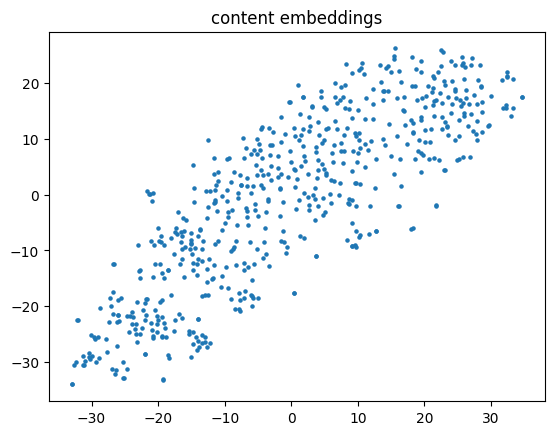

In [222]:
from sklearn.manifold import TSNE
from matplotlib import pyplot as plt
def visualize_embeddings(embeddings, size=10, labels=None, title=''):
    tsne = TSNE(n_components=2, learning_rate='auto')
    tsne_embeddings = tsne.fit_transform(embeddings)

    plt.scatter(tsne_embeddings[:, 0], tsne_embeddings[:, 1], s=size, c=labels)
    plt.title(title)
    plt.show()

visualize_embeddings(embeddings, size=5, title='content embeddings')

## PCA

In [226]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.9, svd_solver='full')
dim_reduced_embeddings = pca.fit_transform(embeddings)
print(f"Dimension reduced embedding shape: {dim_reduced_embeddings.shape}")

df_unique['embeddings'] = list(dim_reduced_embeddings)

Dimension reduced embedding shape: (595, 152)


## K-mean

In [229]:
trueContent_df = df_unique.copy()

Silhouette scores: {2: np.float32(0.09803143), 3: np.float32(0.08772147), 4: np.float32(0.09075134), 5: np.float32(0.07028607), 6: np.float32(0.060832437), 7: np.float32(0.054449), 8: np.float32(0.050031237), 9: np.float32(0.05788508), 10: np.float32(0.053221997), 11: np.float32(0.059557933), 12: np.float32(0.05188284), 13: np.float32(0.05264628), 14: np.float32(0.057535745), 15: np.float32(0.049776368), 16: np.float32(0.056676798), 17: np.float32(0.057143923), 18: np.float32(0.058536727), 19: np.float32(0.050173152), 20: np.float32(0.05727112), 21: np.float32(0.061600655), 22: np.float32(0.05773146), 23: np.float32(0.056796573), 24: np.float32(0.05745542), 25: np.float32(0.061902024), 26: np.float32(0.05530069), 27: np.float32(0.06091112), 28: np.float32(0.055604078), 29: np.float32(0.06278133)}


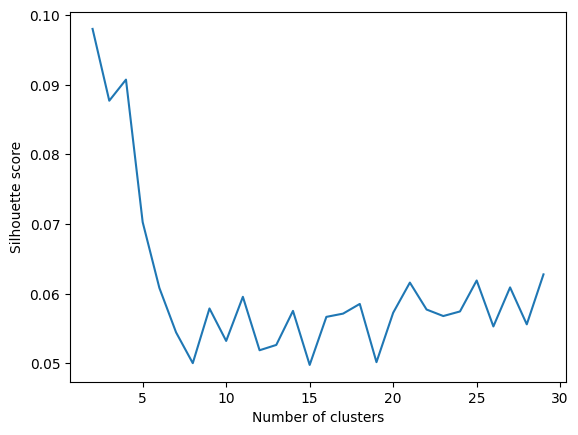

In [231]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
embeddings = [embedding for embedding in trueContent_df['embeddings'].values]

candidate_k_values = list(range(2, 30))
slht_scores, kmeans_labels = [], []
for k in candidate_k_values:
    kmeans = KMeans(n_clusters=k, n_init=20)
    kmeans.fit(embeddings)

    kmeans_labels.append(kmeans.labels_)
    slht_scores.append(silhouette_score(embeddings, kmeans.labels_))

silhouette_score_dict = {candidate_k_values[i]: slht_scores[i] for i in range(len(slht_scores))}

print(f"Silhouette scores: {silhouette_score_dict}")

plt.plot(candidate_k_values, slht_scores)
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
plt.show()

In [240]:
best_k = max(silhouette_score_dict, key=silhouette_score_dict.get)
print(f"Best number of clusters: {best_k}")

Best number of clusters: 2


In [233]:
trueContent_df['cluster'] = kmeans_labels[best_k - candidate_k_values[0]]

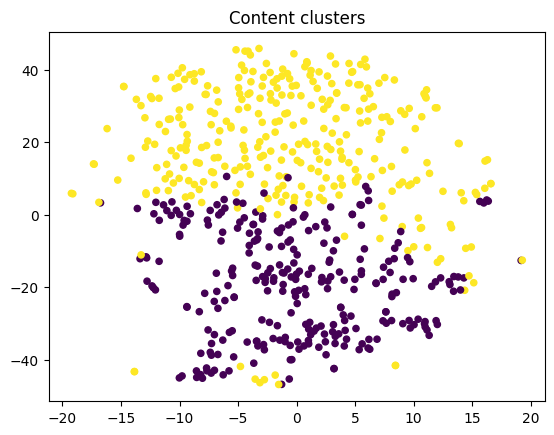

In [234]:
trueContent_embeddings = np.array([embedding for embedding in trueContent_df['embeddings'].values])
visualize_embeddings(trueContent_embeddings, size=20, labels=trueContent_df['cluster'].values, title='Content clusters')

In [235]:
trueContent_df.sort_values(by='cluster', inplace=True)

In [284]:
from collections import Counter

def most_common_words(x):
    word_salad = ' '.join(x.values).lower().split()
    ctr = Counter(word_salad)

    return ctr.most_common(12)

In [285]:
cluster_top_words = (
    trueContent_df
    .groupby('cluster')['sent_norm']
    .apply(most_common_words)
    .reset_index()
)

In [286]:
cluster_top_words[['cluster', 'sent_norm']]

,cluster,sent_norm
0,0,"[(ทรู, 638), (เครื่อง, 530), (ไอโฟน17, 467), (ลูกค้า, 448), (โปรข้ามเวลา, 421), (ไอโฟน, 390), (ดีแทค, 290), (ฟรี, 270), (โปร, 254), (ซื้อ, 226), (ไทย, 155), (ราคา, 139)]"
1,1,"[(โปรข้ามเวลา, 350), (เครื่อง, 268), (ทรู, 206), (ลูกค้า, 199), (เกรด, 125), (โปร, 123), (ประเมิน, 122), (รอย, 104), (บริษัท, 90), (พนักงาน, 89), (รอ, 89), (คน, 88)]"
